# EGFR Dataset QC

This notebook loads the **already processed** M1 dataset and teaches us
how to read the plots before any machine-learning model is trained.

What it does:
1. show the size of the dataset at each major preprocessing stage;
2. look at IC50 and pIC50 distributions;
3. inspect repeated measurements and experimental disagreement;
4. basic chemical QC with molecular weight;
5. show the class balance for the project-defined threshold.

Run the notebook from the project root (`jupyter lab`) or from the
`notebooks/` folder; the path logic below handles both cases.

In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors

# Locate the project root whether we start jupyter from the root
# or from the notebooks/ directory.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")

## 1. Dataset size at each stage

The processing summary written by `preprocess_egfr.py` tells us how many
rows survived each step. This is the first sanity check: if one step
removes an unexpectedly large fraction of the data, we should investigate
before modeling.

In [9]:
import json

summary = json.loads((RESULTS_DIR / "data_processing_summary.json").read_text())

stage_rows = pd.Series(
    {
        "raw_records": summary.get("raw_records"),
        "ic50_records": summary.get("ic50_records"),
        "numeric_records": summary.get("numeric_records"),
        "exact_relation_records": summary.get("exact_relation_records"),
        "supported_unit_records": summary.get("supported_unit_records"),
        "with_structures_records": summary.get("with_structures_records"),
        "valid_smiles_records": summary.get("valid_smiles_records"),
        "standardized_records": summary.get("standardized_records"),
        "unique_final_molecules": summary.get("unique_final_molecules"),
    }
)

print("Rows / molecules at each major stage:")
print(stage_rows.to_string())
print()
print("Excluded counts:")
for key in [
    "excluded_censored_measurements",
    "excluded_unsupported_units",
    "excluded_missing_structures",
    "excluded_invalid_smiles",
]:
    print(f"  {key}: {summary.get(key, 'n/a'):,}")

Rows / molecules at each major stage:
raw_records                17686
ic50_records               17686
numeric_records            17685
exact_relation_records     17685
supported_unit_records     17612
with_structures_records    17595
valid_smiles_records       17595
standardized_records       17595
unique_final_molecules     10161

Excluded counts:
  excluded_censored_measurements: 0
  excluded_unsupported_units: 73
  excluded_missing_structures: 17
  excluded_invalid_smiles: 0


In [10]:
final_df = pd.read_csv(DATA_DIR / "processed" / "egfr_activity_final.csv")
print(f"Final molecule-level dataset shape: {final_df.shape}")
print(f"Columns: {list(final_df.columns)}")
final_df.head()

Final molecule-level dataset shape: (10161, 11)
Columns: ['canonical_smiles', 'pIC50', 'IC50_nM', 'activity_class', 'n_measurements', 'pIC50_std', 'pIC50_min', 'pIC50_max', 'molecule_chembl_id', 'molecule_chembl_ids', 'n_molecules']


,canonical_smiles,pIC50,IC50_nM,activity_class,n_measurements,pIC50_std,pIC50_min,pIC50_max,molecule_chembl_id,molecule_chembl_ids,n_molecules
0,Brc1cc2c(NCc3ccccc3)ncnc2s1,6.617983,241.0,0,1,NaN,6.617983,6.617983,CHEMBL3416599,CHEMBL3416599,1
1,Brc1cc2c(NCc3ccccn3)ncnc2s1,5.102153,7904.0,0,1,NaN,5.102153,5.102153,CHEMBL3416616,CHEMBL3416616,1
2,Brc1cc2c(NCc3cccs3)ncnc2s1,5.862013,1374.0,0,1,NaN,5.862013,5.862013,CHEMBL3416619,CHEMBL3416619,1
3,Brc1cc2c(NCc3ccncc3)ncnc2s1,5.410833,3883.0,0,1,NaN,5.410833,5.410833,CHEMBL3416614,CHEMBL3416614,1
4,Brc1cc2c(Nc3ccccc3)ncnc2s1,7.096910,80.0,1,1,NaN,7.096910,7.096910,CHEMBL3416621,CHEMBL3416621,1


## 2. Activity distributions

We use two related views of the same endpoint.

- **IC50 (nM)** is the experimental concentration. It spans orders of
  magnitude, so we plot it on a log scale. Lower is more potent.
- **pIC50 = 9 - log10(IC50_nM)** is the modeling target: higher is more
  potent, and values are roughly normally distributed, which is friendlier
  for regression models.

What to look for: a single main peak plus a tail toward inactive compounds
is normal for screening data. Two disconnected peaks can mean the dataset
mixes very different assay types or includes a subset of weak binders.

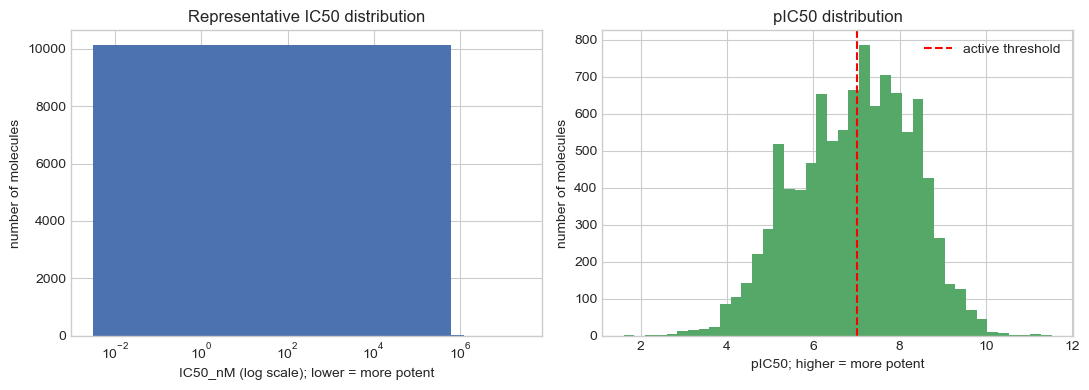

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(final_df["IC50_nM"], bins=40, color="#4C72B0")
axes[0].set_xscale("log")
axes[0].set_xlabel("IC50_nM (log scale); lower = more potent")
axes[0].set_ylabel("number of molecules")
axes[0].set_title("Representative IC50 distribution")

axes[1].hist(final_df["pIC50"], bins=40, color="#55A868")
axes[1].axvline(7.0, color="red", linestyle="--", label="active threshold")
axes[1].set_xlabel("pIC50; higher = more potent")
axes[1].set_ylabel("number of molecules")
axes[1].set_title("pIC50 distribution")
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / "activity_distributions.png", dpi=150)
plt.show()

## 3. Repeated measurements

`n_measurements` counts how many exact IC50 records were aggregated for a
molecule. Molecules with many measurements are more reliable; molecules
with a large `pIC50_std` show disagreement between assays and deserve a
closer look before we trust their single median value.

In [12]:
print("n_measurements distribution (top 10):")
print(final_df["n_measurements"].value_counts().sort_index().head(10).to_string())
print()
print("Compounds with the largest experimental disagreement:")
high_var = final_df.sort_values("pIC50_std", ascending=False).head(10)
print(high_var[["canonical_smiles", "pIC50", "pIC50_std", "n_measurements"]].to_string(index=False))

n_measurements distribution (top 10):
n_measurements
1     6670
2     2179
3      724
4      232
5      120
6      122
7       45
8       29
9        7
10       4

Compounds with the largest experimental disagreement:
                                                                canonical_smiles    pIC50  pIC50_std  n_measurements
                                              O=C(Cc1csc2nc3ccccc3n12)Nc1ccccc1O 4.259637   4.242641               2
                                          O=C(O)CCNc1cc2ncnc(Nc3cccc(Br)c3)c2cn1 7.078883   3.020460               2
CCN1CCC(N2C=C([C@@H](Nc3cc(Cl)c4ncc(C#N)c(Nc5ccc(F)c(Cl)c5)c4c3)c3cccnc3)NN2)CC1 7.199840   2.545810               2
                                               COc1cc2ncnc(Nc3ccc(Br)cc3)c2cc1OC 7.230713   2.527222               2
      C[C@@H](O)c1nc2cnc(Nc3ccnc(N4CC[C@H](O)[C@H](F)C4)n3)cc2n1[C@H](C)C(F)(F)F 5.337437   2.480641               2
                                          C=CC(=O)Nc1ccc2ncnc(Nc3cccc(C)c3F)c2c1

## 4. Basic chemical QC: molecular weight

Molecular weight is a simple sanity descriptor (not a fingerprint; those
come in M2). Drug-like molecules are usually between roughly 150 and 800 Da.
Large outliers may be salts/fragments that survived standardization, or
macrocycle-like structures that deserve a manual look.

Molecules with MolWt computed: 10,161
count    10161.000000
mean       483.141039
std        120.579545
min         65.390000
25%        404.293000
50%        483.956000
75%        556.417000
max       1425.805000


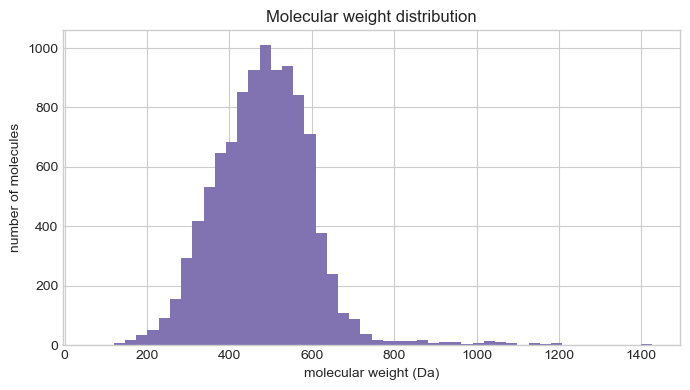

In [13]:
def compute_molwt(smiles: str) -> float | None:
    mol = Chem.MolFromSmiles(smiles)
    return Descriptors.MolWt(mol) if mol is not None else None

final_df["MolWt"] = final_df["canonical_smiles"].map(compute_molwt)

print(f"Molecules with MolWt computed: {final_df['MolWt'].notna().sum():,}")
print(final_df["MolWt"].describe().to_string())

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(final_df["MolWt"].dropna(), bins=50, color="#8172B2")
ax.set_xlabel("molecular weight (Da)")
ax.set_ylabel("number of molecules")
ax.set_title("Molecular weight distribution")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "molecular_weight.png", dpi=150)
plt.show()

## 5. Classification balance

The optional `activity_class` uses the project threshold pIC50 >= 7.
This is a **project-defined educational threshold**, not a universal
biological definition. The balance matters because a heavily imbalanced
dataset affects which metrics we trust in M2/M3.

active (pIC50 >= 7):  5,261
inactive (pIC50 < 7): 4,900


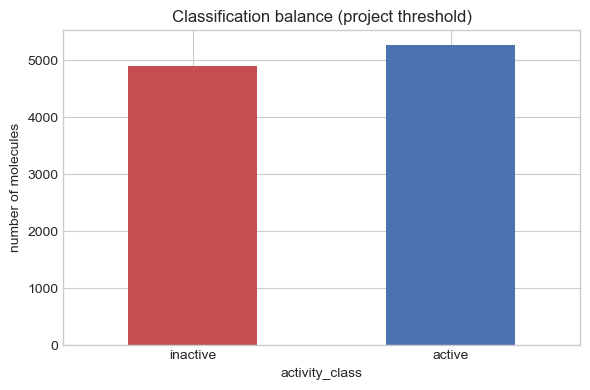

In [14]:
class_counts = final_df["activity_class"].value_counts().sort_index()
print(f"active (pIC50 >= 7):  {class_counts.get(1, 0):,}")
print(f"inactive (pIC50 < 7): {class_counts.get(0, 0):,}")

fig, ax = plt.subplots(figsize=(6, 4))
class_counts.plot(kind="bar", color=["#C44E52", "#4C72B0"], ax=ax)
ax.set_xticklabels(["inactive", "active"], rotation=0)
ax.set_ylabel("number of molecules")
ax.set_title("Classification balance (project threshold)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "classification_balance.png", dpi=150)
plt.show()

## 6. Before machine learning: what to check

1. **Is the endpoint homogeneous?** We only kept exact IC50 measurements;
   censored values are excluded and reported.
2. **Is the chemical space diverse?** The pIC50 histogram and molecular
   weight range give a first impression. A later scaffold split (M3) will
   test generalization more rigorously.
3. **Are repeated measurements consistent?** Large `pIC50_std` compounds are
   candidates for manual review before trusting their label.
4. **Is the class balance acceptable?** If one class dominates, M2/M3 should
   use appropriate metrics (AUC, balanced accuracy).

M1 is complete when these plots and the processing summary make sense to
your tutor. Then we can start M2 (Morgan fingerprints + classical ML).